# DeepCNN Multi-Input — Cinsiyet Bilgisi Entegrasyonu

Mevcut 5 modelden en iyi sonucu veren **DeepCNN** mimarisi, cinsiyet bilgisi eklenerek genişletilmektedir.

| Dal | Girdi | Çıktı |
|---|---|---|
| Görüntü Dalı | 128×128×3 X-ray | 256 boyutlu özellik vektörü |
| Cinsiyet Dalı | 0 (Kız) / 1 (Erkek) | 16 boyutlu özellik |
| Birleştirme | Concatenate | → Dense → Regresyon çıktısı |

Eski benchmark sonuçları `benchmark_ara_kayit.csv` dosyasından yüklenerek karşılaştırma yapılacaktır.

---
## 1. Import ve Ayarlar

In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

BASE_DIR      = Path(".").resolve()
DATA_DIR      = BASE_DIR / "data"
OUTPUT_DIR    = BASE_DIR / "outputs"
FIGURES_DIR   = OUTPUT_DIR / "figures"
MODELS_DIR    = OUTPUT_DIR / "models"
REPORTS_DIR   = OUTPUT_DIR / "reports"

TRAIN_CSV     = DATA_DIR / "boneage-training-dataset.csv"
IMG_SIZE      = (128, 128)
BATCH_SIZE    = 64
EPOCHS        = 25
RANDOM_STATE  = 42
BONEAGE_COL   = "boneage"
GENDER_COL    = "male"

def find_image_dir(base):
    candidates = [
        base / "boneage-training-dataset",
        base / "boneage-training-dataset" / "boneage-training-dataset",
    ]
    for c in candidates:
        if c.exists() and any(c.glob("*.png")):
            return c
    for p in base.rglob("*.png"):
        return p.parent
    return candidates[0]

TRAIN_IMG_DIR = find_image_dir(DATA_DIR)

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"IMG_SIZE   : {IMG_SIZE}")
print(f"Görüntü klasörü: {TRAIN_IMG_DIR}")

TensorFlow : 2.19.0
GPU        : False
IMG_SIZE   : (128, 128)
Görüntü klasörü: C:\Users\Can\Desktop\data\boneage-training-dataset\boneage-training-dataset


---
## 2. Veri Yükleme ve Split

Aynı `random_state=42` ile mevcut notebook ile aynı split oluşturulmaktadır.

In [2]:
train_df = pd.read_csv(TRAIN_CSV)
id_col   = train_df.columns[0]

def find_image_path(img_id, img_dir):
    for ext in [".png", ".jpg", ".jpeg"]:
        p = img_dir / f"{img_id}{ext}"
        if p.exists():
            return str(p)
    return None

train_df["img_path"] = train_df[id_col].astype(str).apply(
    lambda x: find_image_path(x, TRAIN_IMG_DIR)
)
train_df = train_df.dropna(subset=["img_path"]).reset_index(drop=True)

train_df["boneage_bin"] = pd.cut(train_df[BONEAGE_COL], bins=10, labels=False)

df_train_full, df_test = train_test_split(
    train_df, test_size=0.15,
    stratify=train_df["boneage_bin"], random_state=RANDOM_STATE
)
df_train, df_val = train_test_split(
    df_train_full, test_size=0.15/0.85,
    stratify=df_train_full["boneage_bin"], random_state=RANDOM_STATE
)

print(f"Train      : {len(df_train)}")
print(f"Validation : {len(df_val)}")
print(f"Test       : {len(df_test)}")
print(f"Erkek oranı: %{df_train[GENDER_COL].isin([True,1]).mean()*100:.1f}")

Train      : 8827
Validation : 1892
Test       : 1892
Erkek oranı: %54.2


---
## 3. Multi-Input Dataset Pipeline

Standart pipeline'dan farkı: görüntü tek başına değil, **cinsiyet bilgisiyle birlikte** modele giriyor.

In [3]:
def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = img / (tf.reduce_max(img) + 1e-8)
    return img

def build_multi_dataset(df, augment=False, shuffle=True):
    paths   = df["img_path"].values
    genders = df[GENDER_COL].astype(float).values.astype("float32")
    labels  = df[BONEAGE_COL].astype("float32").values

    ds = tf.data.Dataset.from_tensor_slices(((paths, genders), labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=RANDOM_STATE)

    def process(inputs, label):
        img_path, gender = inputs
        img = load_image(img_path)
        return (img, tf.expand_dims(gender, axis=0)), label

    ds = ds.map(process, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        aug = keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.05),
            layers.RandomZoom(0.1),
        ])
        def augment_fn(inputs, label):
            img, gender = inputs
            return (aug(img, training=True), gender), label
        ds = ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)

    return ds.cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds_mi = build_multi_dataset(df_train, augment=True,  shuffle=True)
val_ds_mi   = build_multi_dataset(df_val,   augment=False, shuffle=False)
test_ds_mi  = build_multi_dataset(df_test,  augment=False, shuffle=False)

for (imgs, genders), labels in train_ds_mi.take(1):
    print(f"Görüntü batch shape : {imgs.shape}")
    print(f"Cinsiyet batch shape: {genders.shape}")
    print(f"Label batch shape   : {labels.shape}")
    print(f"Piksel min/max      : {imgs.numpy().min():.4f} / {imgs.numpy().max():.4f}")
    print(f"Cinsiyet örnekler   : {genders.numpy().flatten()[:8]}")

Görüntü batch shape : (64, 128, 128, 3)
Cinsiyet batch shape: (64, 1)
Label batch shape   : (64,)
Piksel min/max      : 0.0000 / 1.0000
Cinsiyet örnekler   : [0. 1. 0. 1. 1. 1. 0. 1.]


---
## 4. Multi-Input DeepCNN Mimarisi

İki daldan oluşmaktadır:
- **Görüntü dalı:** 4 konvolüsyon bloğu + BatchNormalization
- **Cinsiyet dalı:** Tek sayısal girdi → Dense(16)
- **Birleştirme:** Concatenate → Dropout → Dense(128) → Dense(64) → çıktı

In [4]:
def build_deepcnn_multi_input(input_shape=(*IMG_SIZE, 3)):
    img_input = keras.Input(shape=input_shape, name="image_input")

    x = layers.Conv2D(32, 3, activation="relu", padding="same")(img_input)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(256, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    img_features = layers.Dense(256, activation="relu", name="img_features")(x)

    gender_input = keras.Input(shape=(1,), name="gender_input")
    g = layers.Dense(16, activation="relu", name="gender_features")(gender_input)

    merged = layers.Concatenate(name="merge")([img_features, g])
    merged = layers.Dropout(0.4)(merged)
    merged = layers.Dense(128, activation="relu")(merged)
    merged = layers.Dense(64, activation="relu")(merged)
    output = layers.Dense(1, activation="linear", name="boneage_output")(merged)

    return keras.Model(
        inputs=[img_input, gender_input],
        outputs=output,
        name="DeepCNN_MultiInput"
    )

model_mi = build_deepcnn_multi_input()
model_mi.summary()

total_params = model_mi.count_params()
print(f"\nToplam parametre: {total_params:,}")

Model: "DeepCNN_MultiInput"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_input        │ (None, 1)         │          0 │ -               

 Total params: 693,185 (2.64 MB)

 Trainable params: 692,225 (2.64 MB)

 Non-trainable params: 960 (3.75 KB)


Toplam parametre: 693,185


In [5]:
keras.utils.plot_model(
    model_mi,
    show_shapes=True,
    show_layer_names=True,
    rankdir="TB",
    expand_nested=False
)

You must install pydot (`pip install pydot`) for `plot_model` to work.


---
## 5. Eğitim

In [6]:
model_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_loss", patience=5,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=3, min_lr=1e-7, verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=str(MODELS_DIR / "DeepCNN_MultiInput_best.keras"),
        monitor="val_loss", save_best_only=True, verbose=0
    ),
]

model_mi.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="mae",
    metrics=["mae"]
)

print("Eğitim başlıyor...")
print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")
print("="*60)

start = time.time()
history_mi = model_mi.fit(
    train_ds_mi,
    validation_data=val_ds_mi,
    epochs=EPOCHS,
    callbacks=model_callbacks,
    verbose=1
)
elapsed_mi = round(time.time() - start, 1)

print(f"\nEğitim tamamlandı: {elapsed_mi} saniye")

Eğitim başlıyor...
Train: 8827 | Val: 1892 | Test: 1892
Epoch 1/25
138/138 ━━━━━━━━━━━━━━━━━━━━ 80s 563ms/step - loss: 70.9035 - mae: 70.9035 - val_loss: 53.2284 - val_mae: 53.2284 - learning_rate: 0.0010
Epoch 2/25
138/138 ━━━━━━━━━━━━━━━━━━━━ 69s 500ms/step - loss: 32.5929 - mae: 32.5929 - val_loss: 50.7132 - val_mae: 50.7132 - learning_rate: 0.0010
Epoch 3/25
138/138 ━━━━━━━━━━━━━━━━━━━━ 74s 537ms/step - loss: 30.4562 - mae: 30.4562 - val_loss: 40.2395 - val_mae: 40.2395 - learning_rate: 0.0010
Epoch 4/25
138/138 ━━━━━━━━━━━━━━━━━━━━ 81s 588ms/step - loss: 28.9934 - mae: 28.9934 - val_loss: 39.8138 - val_mae: 39.8138 - learning_rate: 0.0010
Epoch 5/25
138/138 ━━━━━━━━━━━━━━━━━━━━ 90s 651ms/step - loss: 27.7728 - mae: 27.7728 - val_loss: 39.4255 - val_mae: 39.4255 - learning_rate: 0.0010
Epoch 6/25
138/138 ━━━━━━━━━━━━━━━━━━━━ 81s 587ms/step - loss: 26.2081 - mae: 26.2081 - val_loss: 27.4930 - val_mae: 27.4930 - learning_rate: 0.0010
Epoch 7/25
138/138 ━━━━━━━━━━━━━━━━━━━━ 75s 541ms/

---
## 6. Test Seti Değerlendirmesi

In [7]:
y_pred_mi = model_mi.predict(test_ds_mi, verbose=0).flatten()
y_true    = df_test[BONEAGE_COL].values.astype("float32")

mae_mi  = round(float(mean_absolute_error(y_true, y_pred_mi)), 2)
mse_mi  = round(float(mean_squared_error(y_true, y_pred_mi)), 2)
rmse_mi = round(float(np.sqrt(mse_mi)), 2)
r2_mi   = round(float(r2_score(y_true, y_pred_mi)), 4)

print("="*50)
print("  DeepCNN Multi-Input Sonuçları")
print("="*50)
print(f"  MAE   : {mae_mi} ay")
print(f"  MSE   : {mse_mi}")
print(f"  RMSE  : {rmse_mi} ay")
print(f"  R²    : {r2_mi}")
print(f"  Süre  : {elapsed_mi} sn")

  DeepCNN Multi-Input Sonuçları
  MAE   : 15.35 ay
  MSE   : 474.76
  RMSE  : 21.79 ay
  R²    : 0.7221
  Süre  : 1528.9 sn


---
## 7. Eski Benchmark ile Karşılaştırma

In [8]:
eski_df = pd.read_csv(REPORTS_DIR / "benchmark_ara_kayit.csv")

yeni_satir = pd.DataFrame([{
    "Model"             : "DeepCNN_MultiInput",
    "MAE (ay)"          : mae_mi,
    "MSE"               : mse_mi,
    "RMSE (ay)"         : rmse_mi,
    "R²"                : r2_mi,
    "Val Loss (son)"    : round(min(history_mi.history["val_loss"]), 2),
    "Eğitim Süresi (s)" : elapsed_mi,
    "Parametre Sayısı"  : model_mi.count_params(),
}])

tam_df = pd.concat([eski_df, yeni_satir], ignore_index=True).sort_values("MAE (ay)").reset_index(drop=True)
tam_df.to_csv(REPORTS_DIR / "benchmark_final.csv", index=False)

print(tam_df[[
    "Model","MAE (ay)","RMSE (ay)","R²","Eğitim Süresi (s)"
]].to_string(index=False))

best_model_name = tam_df.iloc[0]["Model"]
print(f"\n🏆 En iyi model: {best_model_name}")
print(f"   MAE  : {tam_df.iloc[0]['MAE (ay)']} ay")
print(f"   RMSE : {tam_df.iloc[0]['RMSE (ay)']} ay")
print(f"   R²   : {tam_df.iloc[0]['R²']}")

             Model  MAE (ay)  RMSE (ay)      R²  Eğitim Süresi (s)
DeepCNN_MultiInput     15.35      21.79  0.7221             1528.9
           DeepCNN     17.61      23.67  0.6721             2070.1
       DenseNet121     22.05      28.03  0.5401             1242.6
       MobileNetV2     25.13      31.92  0.4036              213.4
    EfficientNetB0     33.34      42.45 -0.0550              143.6
         SimpleCNN     33.60      42.29 -0.0468              121.4

🏆 En iyi model: DeepCNN_MultiInput
   MAE  : 15.35 ay
   RMSE : 21.79 ay
   R²   : 0.7221


---
## 8. Grafikler

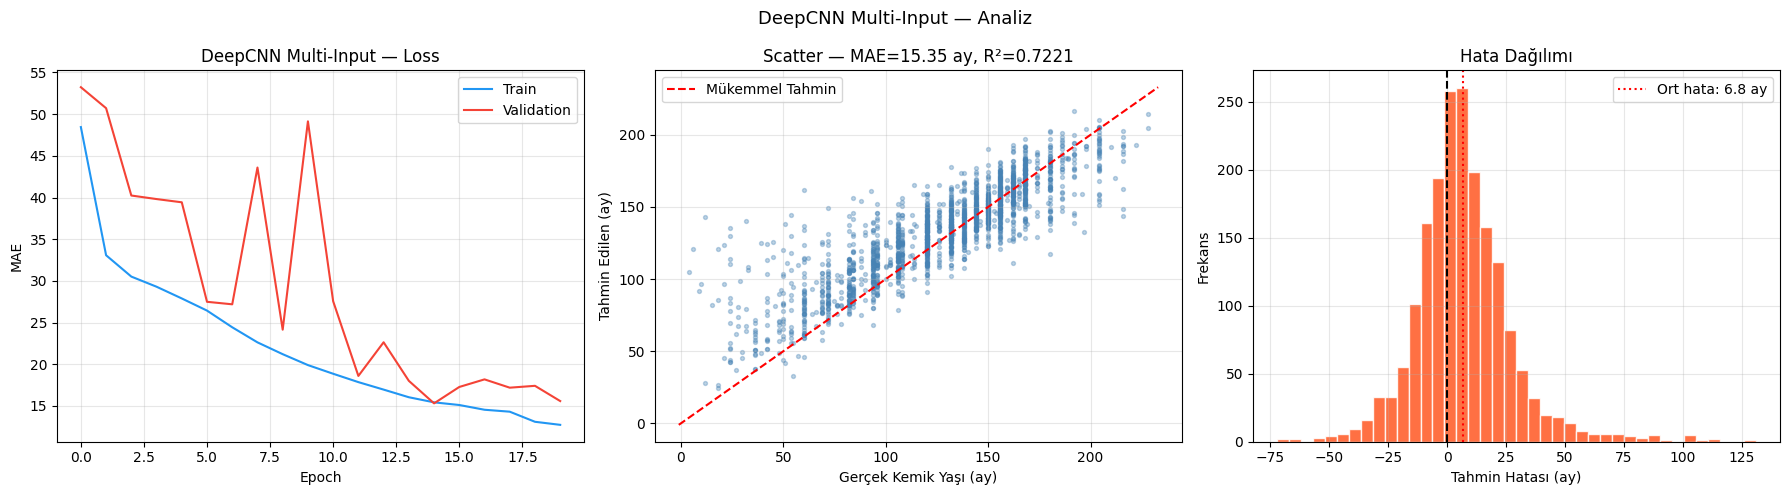

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_mi.history["loss"],     color="#2196F3", label="Train")
axes[0].plot(history_mi.history["val_loss"], color="#F44336", label="Validation")
axes[0].set_title("DeepCNN Multi-Input — Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MAE")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(y_true, y_pred_mi, alpha=0.35, s=8, color="steelblue")
lim = [min(y_true.min(), y_pred_mi.min())-5, max(y_true.max(), y_pred_mi.max())+5]
axes[1].plot(lim, lim, "r--", lw=1.5, label="Mükemmel Tahmin")
axes[1].set_xlabel("Gerçek Kemik Yaşı (ay)")
axes[1].set_ylabel("Tahmin Edilen (ay)")
axes[1].set_title(f"Scatter — MAE={mae_mi:.2f} ay, R²={r2_mi:.4f}")
axes[1].legend()
axes[1].grid(alpha=0.3)

errors = y_pred_mi - y_true
axes[2].hist(errors, bins=40, color="#FF5722", edgecolor="white", alpha=0.85)
axes[2].axvline(0, color="black", linestyle="--", lw=1.5)
axes[2].axvline(errors.mean(), color="red", linestyle=":", lw=1.5,
                label=f"Ort hata: {errors.mean():.1f} ay")
axes[2].set_xlabel("Tahmin Hatası (ay)")
axes[2].set_ylabel("Frekans")
axes[2].set_title("Hata Dağılımı")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle("DeepCNN Multi-Input — Analiz", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "10_multiinput_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

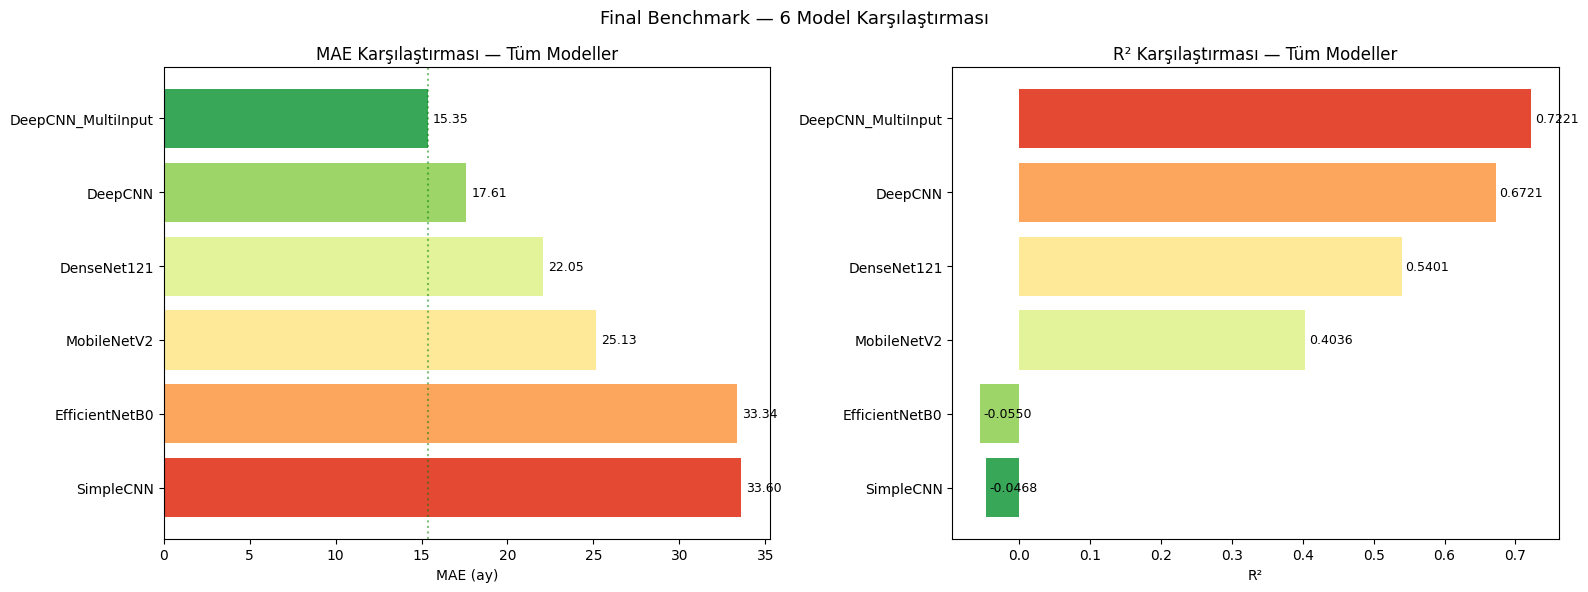

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = sns.color_palette("RdYlGn_r", len(tam_df))

bars = axes[0].barh(tam_df["Model"], tam_df["MAE (ay)"], color=colors)
for i, v in enumerate(tam_df["MAE (ay)"]):
    axes[0].text(v+0.3, i, f"{v:.2f}", va="center", fontsize=9)
axes[0].set_title("MAE Karşılaştırması — Tüm Modeller")
axes[0].set_xlabel("MAE (ay)")
axes[0].invert_yaxis()
axes[0].axvline(tam_df["MAE (ay)"].min(), color="green", linestyle=":", alpha=0.5)

r2_colors = sns.color_palette("RdYlGn", len(tam_df))
bars2 = axes[1].barh(tam_df["Model"], tam_df["R²"],
                     color=sns.color_palette("RdYlGn", len(tam_df)))
for i, v in enumerate(tam_df["R²"]):
    axes[1].text(v+0.005, i, f"{v:.4f}", va="center", fontsize=9)
axes[1].set_title("R² Karşılaştırması — Tüm Modeller")
axes[1].set_xlabel("R²")
axes[1].invert_yaxis()

plt.suptitle("Final Benchmark — 6 Model Karşılaştırması", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "11_final_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 9. Confusion Matrix

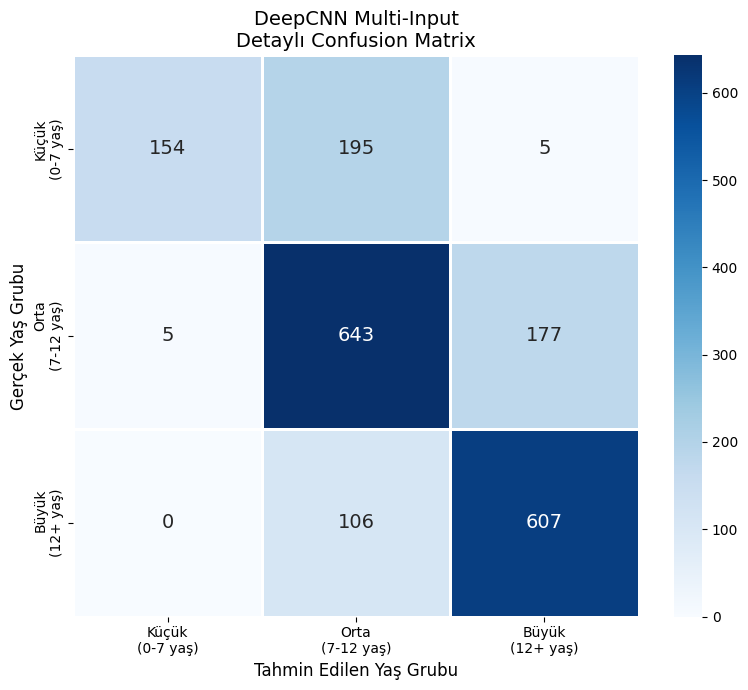

Yaş grubu doğruluğu : %74.2  (1404/1892)
Önceki DeepCNN      : %68.5


In [11]:
def get_age_category(months_array):
    bins   = [0, 84, 144, 999]
    labels = ["Küçük\n(0-7 yaş)", "Orta\n(7-12 yaş)", "Büyük\n(12+ yaş)"]
    return pd.cut(pd.Series(months_array), bins=bins, labels=labels).astype(str)

CLASS_LABELS = ["Küçük\n(0-7 yaş)", "Orta\n(7-12 yaş)", "Büyük\n(12+ yaş)"]

true_cats = get_age_category(y_true)
pred_cats = get_age_category(y_pred_mi)
cm = confusion_matrix(true_cats, pred_cats, labels=CLASS_LABELS)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS,
            linewidths=1, linecolor="white", ax=ax, annot_kws={"size": 14})
ax.set_title("DeepCNN Multi-Input\nDetaylı Confusion Matrix", fontsize=14)
ax.set_xlabel("Tahmin Edilen Yaş Grubu", fontsize=12)
ax.set_ylabel("Gerçek Yaş Grubu", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "12_multiinput_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

correct = np.diag(cm).sum()
total   = cm.sum()
print(f"Yaş grubu doğruluğu : %{correct/total*100:.1f}  ({correct}/{total})")
print(f"Önceki DeepCNN      : %68.5")

---
## 10. Özet

In [12]:
print("="*60)
print("  MULTI-INPUT MODEL SONUÇLARI")
print("="*60)
print()

onceki = eski_df[eski_df["Model"]=="DeepCNN"].iloc[0]
print("  Önceki DeepCNN (tek girdi):")
print(f"    MAE  : {onceki['MAE (ay)']} ay")
print(f"    RMSE : {onceki['RMSE (ay)']} ay")
print(f"    R²   : {onceki['R²']}")
print()
print("  DeepCNN Multi-Input (görüntü + cinsiyet):")
print(f"    MAE  : {mae_mi} ay")
print(f"    RMSE : {rmse_mi} ay")
print(f"    R²   : {r2_mi}")
print()

mae_imp  = round(float(onceki['MAE (ay)']) - mae_mi, 2)
r2_imp   = round(r2_mi - float(onceki['R²']), 4)
print(f"  İyileşme → MAE: {mae_imp:+.2f} ay  |  R²: {r2_imp:+.4f}")
print()
print(f"  Final en iyi model : {best_model_name}")
print()
print("  Kaydedilen dosyalar:")
print(f"    Model   : outputs/models/DeepCNN_MultiInput_best.keras")
print(f"    Grafik  : outputs/figures/10_multiinput_analysis.png")
print(f"    Benchmark: outputs/reports/benchmark_final.csv")

  MULTI-INPUT MODEL SONUÇLARI

  Önceki DeepCNN (tek girdi):
    MAE  : 17.61 ay
    RMSE : 23.67 ay
    R²   : 0.6721

  DeepCNN Multi-Input (görüntü + cinsiyet):
    MAE  : 15.35 ay
    RMSE : 21.79 ay
    R²   : 0.7221

  İyileşme → MAE: +2.26 ay  |  R²: +0.0500

  Final en iyi model : DeepCNN_MultiInput

  Kaydedilen dosyalar:
    Model   : outputs/models/DeepCNN_MultiInput_best.keras
    Grafik  : outputs/figures/10_multiinput_analysis.png
    Benchmark: outputs/reports/benchmark_final.csv
